I am no expert in debugging Bayesian models. Generally, to me, debugging divergences is the most frustrating part about working with Bayesian models - so far, I am yet to find a good tutorial on how to go about debugging models. Typically, [suggestions](https://www.pymc.io/projects/examples/en/latest/diagnostics_and_criticism/Diagnosing_biased_Inference_with_Divergences.html) are to reparameterize, try different step sizes and revisit priors. 


In [ ]:
better_priors = {
    'η': 2,
    'α': (0.5, 0.7),
    'S': (0, 0.5),
    'N': (1, 0.5),
    'p': np.ones(28 - 1),
    'β': (-2, 1)
}

adj_priors = {
    'η': 2,
    'α': (0.5, 0.7),
    'S': (0, 0.5),
    'N': (0.5, 0.5),
    'p': np.ones(28 - 1),
    'β': (-1, 0.5)
}

settings = {
    'base': dict(priors=priors, hierarchical=True, model_with_offset=False),
    'wide': dict(priors=wider_priors, hierarchical=True, model_with_offset=False),
    'better': dict(priors=better_priors, hierarchical=True, model_with_offset=False),
    'adj': dict(priors=adj_priors, hierarchical=True, model_with_offset=False)
}

settings = {
    'adj': dict(priors=adj_priors, hierarchical=True, model_with_offset=True)
}

In [ ]:
iters = 10
results = []
save_stuck = True

for name, params in tqdm(settings.items()):
    m = modelling.compile_pymc(sc2_group_df, **params)

    new_rng = np.random.default_rng(42)
    
    for i in tqdm(range(iters)):
        tr = modelling.fit_pymc(rng=new_rng, model = m)  
        stuck = stuck_chains(tr)      
        results.append({
            'priors': name,
            'iteration': i,
            'max_rhat': max_rhat(tr),
            'stuck_chains': stuck,
            'divergences': int(tr['sample_stats']['diverging'].sum())
        })
        #save an example chain
        if stuck > 0 and save_stuck:
            tr.to_netcdf(f"traces/stuck_chain.netcdf")
            save_stuck = False

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

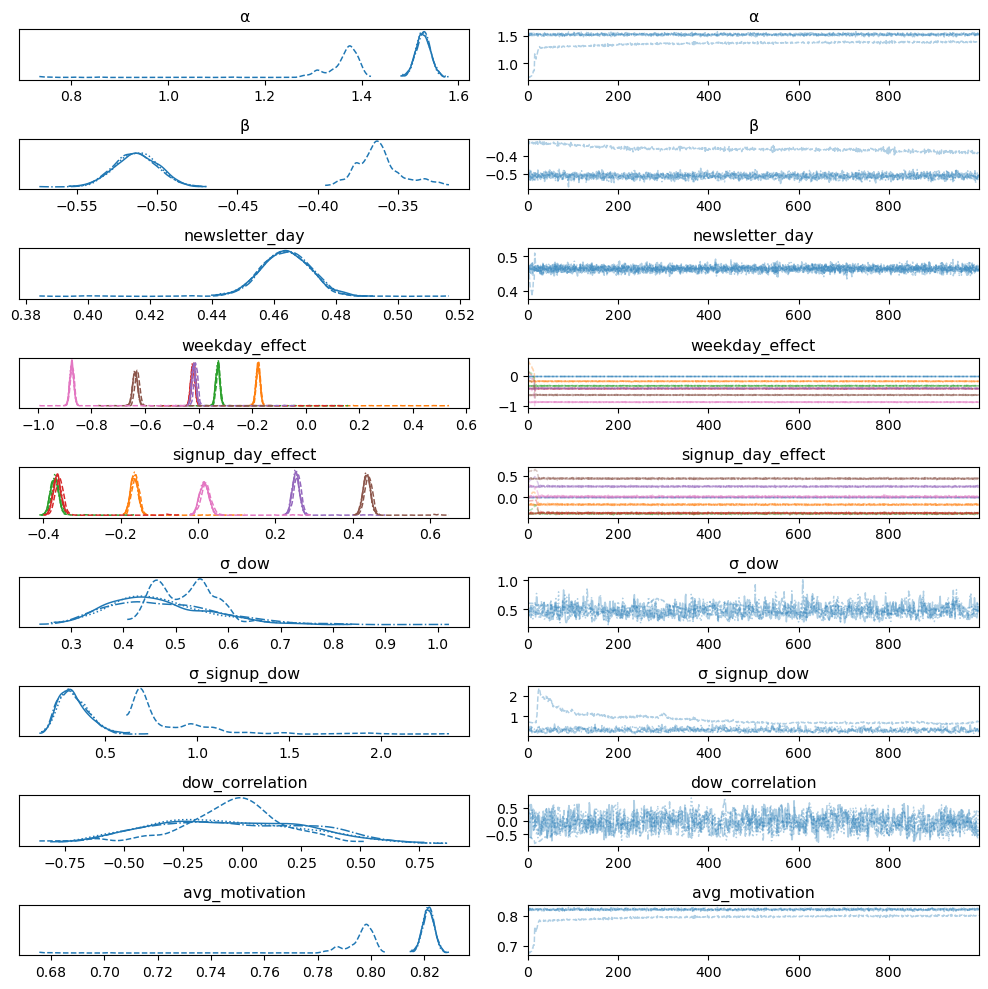

In [ ]:
plotting.plot_trace(tr)

In [ ]:
df_res = pd.DataFrame(results)
df_res['converged'] = df_res['max_rhat'] < 1.03
df_res['diverged'] = (df_res['divergences'] - df_res['stuck_chains']*1000) > 0
df_res['stuck'] = df_res['stuck_chains'] > 0
df_res

,priors,iteration,max_rhat,stuck_chains,divergences,converged,diverged,stuck
0,adj,0,1.532836,1,1000,False,False,True
1,adj,1,1.530042,1,1000,False,False,True
2,adj,2,1.005195,0,0,True,False,False
3,adj,3,1.599149,0,975,False,True,False
4,adj,4,1.583237,0,0,False,False,False
5,adj,5,3.411722,2,2000,False,False,True
6,adj,6,1.582863,0,0,False,False,False
7,adj,7,1.005564,0,0,True,False,False
8,adj,8,1.003750,0,0,True,False,False
9,adj,9,1.601123,0,0,False,False,False


In [ ]:
def max_rhat(t, vars=['α', 'β', 'Z', 'chol_cov', 'tenure_prop', 'newsletter_day']):
    return float(az.rhat(
        t, 
        var_names=vars
    ).max().to_array().max())

def stuck_chains(t, vars=['β']):
    return int(t['posterior'].get(
        vars
    ).std(dim=['draw']).apply(lambda x: np.isclose(x, 0)).to_array().sum())